# EXPERIMENT 6

## Lasso, Ridge and Elastic Net Regularization

### Objective

The objective is to study how regularisation affects Logistic Regression.

- Compare Lasso, Ridge and Elastic Net.
- Study validation accuracy for different C values.
- Observe coefficient shrinkage.
- Count non-zero coefficients for Lasso and Ridge.
- Return all results in a Pandas DataFrame.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv


In [3]:
import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (50000, 32)
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             4

In [4]:
print(df.columns.tolist())
print(df["PlacementStatus"].value_counts())

['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64


In [5]:
target = "PlacementStatus"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (50000, 31)
y shape: (50000,)

Target distribution:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64


In [6]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded X shape:", X.shape)

Encoded X shape: (50000, 47)


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (40000, 47)
X_val: (10000, 47)
y_train: (40000,)
y_val: (10000,)


In [8]:
print("Missing values in X:")
print(X.isna().sum().sort_values(ascending=False).head(20))

print("\nTotal missing values:", X.isna().sum().sum())

Missing values in X:
MockInterviewScore    4957
Workshops             4488
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
SGPA_Sem1                0
StudentID                0
SGPA_Sem6                0
SGPA_Sem7                0
CGPA                     0
SGPA_Sem8                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem2                0
Certifications           0
Projects                 0
Internships              0
AttendancePercent        0
Publications             0
dtype: int64

Total missing values: 19976


In [9]:
X = X.replace([np.inf, -np.inf], np.nan)

print(
    "Missing values after replacing infinity:",
    X.isna().sum().sum()
)

Missing values after replacing infinity: 19976


In [10]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

print(
    "Training missing values:",
    np.isnan(X_train_imputed).sum()
)

print(
    "Validation missing values:",
    np.isnan(X_val_imputed).sum()
)

Training missing values: 0
Validation missing values: 0


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)

X_train_scaled: (40000, 47)
X_val_scaled: (10000, 47)


In [12]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

In [17]:
def compare_regularisation(X_train, y_train, X_val, y_val, C_values):
    results = []

    for C in C_values:
        lasso = LogisticRegression(
            penalty="l1",
            C=C,
            solver="liblinear",
            max_iter=2000,
            random_state=42
        )

        lasso.fit(X_train, y_train)
        lasso_pred = lasso.predict(X_val)
        lasso_acc = accuracy_score(y_val, lasso_pred)

        lasso_nonzero = np.sum(
            np.abs(lasso.coef_) > 1e-6
        )

        ridge = LogisticRegression(
            penalty="l2",
            C=C,
            solver="liblinear",
            max_iter=2000,
            random_state=42
        )

        ridge.fit(X_train, y_train)
        ridge_pred = ridge.predict(X_val)
        ridge_acc = accuracy_score(y_val, ridge_pred)

        ridge_nonzero = np.sum(
            np.abs(ridge.coef_) > 1e-6
        )

        elastic = LogisticRegression(
            penalty="elasticnet",
            C=C,
            l1_ratio=0.5,
            solver="saga",
            max_iter=1000,
            tol=1e-3,
            random_state=42
        )

        elastic.fit(X_train, y_train)
        elastic_pred = elastic.predict(X_val)
        elastic_acc = accuracy_score(y_val, elastic_pred)

        results.append({
            "C": C,
            "Lasso_val_acc": lasso_acc,
            "Ridge_val_acc": ridge_acc,
            "ElasticNet_val_acc": elastic_acc,
            "Lasso_nonzero": lasso_nonzero,
            "Ridge_nonzero": ridge_nonzero
        })

    return pd.DataFrame(results)

In [18]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

results_df = compare_regularisation(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    C_values
)

results_df

,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
0,0.001,0.9685,0.9461,0.9780,11,47
1,0.010,0.9971,0.9911,0.9954,14,47
2,0.100,0.9981,0.9974,0.9976,24,47
3,1.000,0.9981,0.9981,0.9981,40,47
4,10.000,0.9982,0.9981,0.9981,47,47
5,100.000,0.9982,0.9982,0.9982,47,47


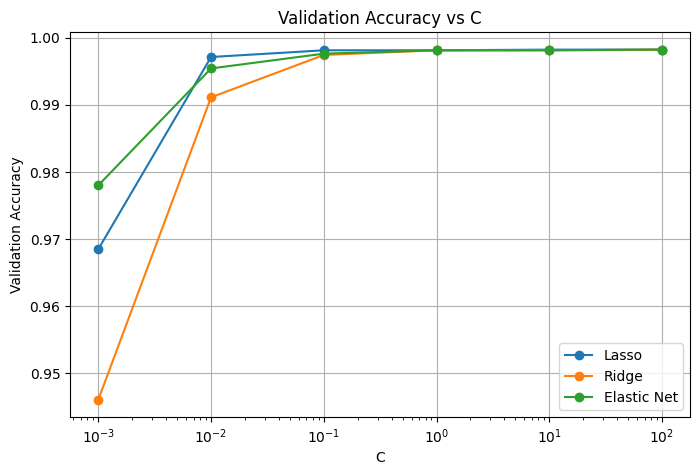

In [19]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    results_df["C"],
    results_df["Lasso_val_acc"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results_df["C"],
    results_df["Ridge_val_acc"],
    marker="o",
    label="Ridge"
)

plt.semilogx(
    results_df["C"],
    results_df["ElasticNet_val_acc"],
    marker="o",
    label="Elastic Net"
)

plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs C")
plt.legend()
plt.grid(True)
plt.show()

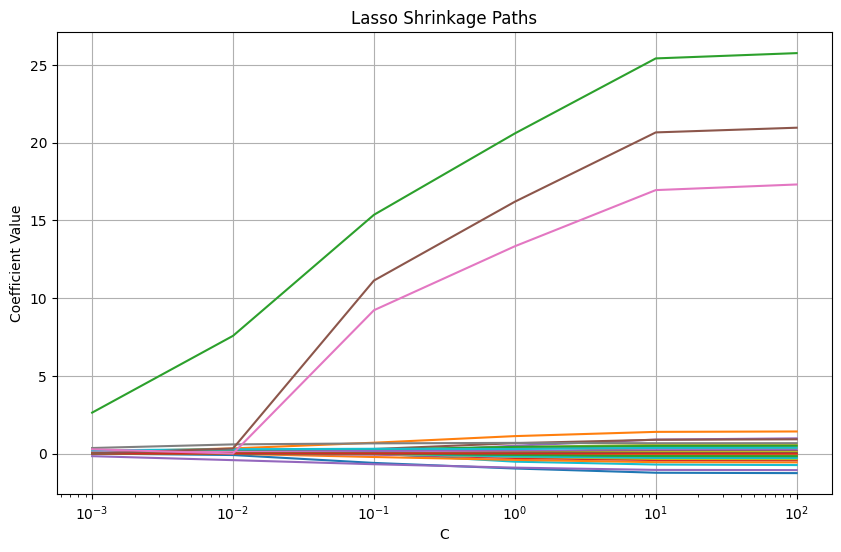

In [20]:
lasso_coefficients = []

for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)
    lasso_coefficients.append(model.coef_[0])

lasso_coefficients = np.array(lasso_coefficients)

plt.figure(figsize=(10, 6))

for i in range(lasso_coefficients.shape[1]):
    plt.semilogx(
        C_values,
        lasso_coefficients[:, i]
    )

plt.xlabel("C")
plt.ylabel("Coefficient Value")
plt.title("Lasso Shrinkage Paths")
plt.grid(True)
plt.show()

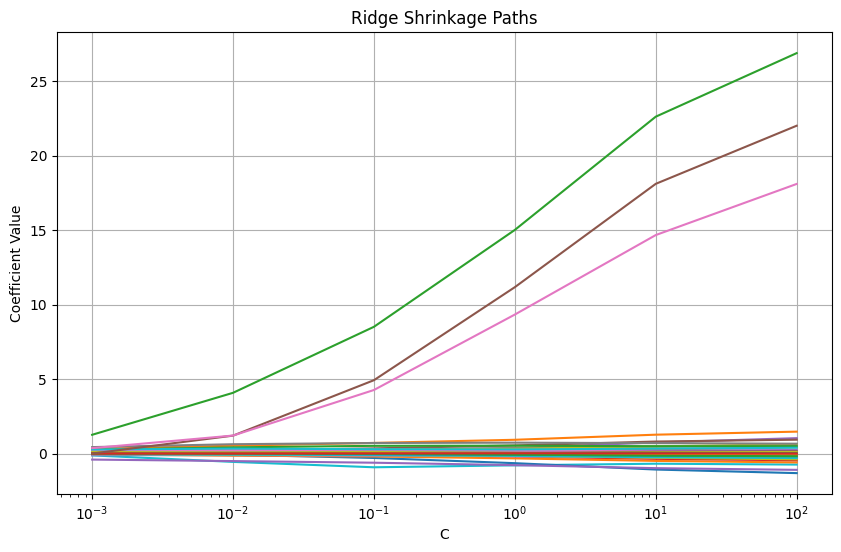

In [21]:
ridge_coefficients = []

for C in C_values:
    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)
    ridge_coefficients.append(model.coef_[0])

ridge_coefficients = np.array(ridge_coefficients)

plt.figure(figsize=(10, 6))

for i in range(ridge_coefficients.shape[1]):
    plt.semilogx(
        C_values,
        ridge_coefficients[:, i]
    )

plt.xlabel("C")
plt.ylabel("Coefficient Value")
plt.title("Ridge Shrinkage Paths")
plt.grid(True)
plt.show()